# Model Training & Evaluation — v1

This notebook documents the full model training process:

1. Establish baselines (naive + ELO-only)
2. Train XGBoost, LightGBM, and Ensemble
3. Evaluate with proper metrics
4. Analyze feature importance
5. Confusion matrix and error analysis
6. Compare all models head-to-head

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve
)
from sklearn.calibration import calibration_curve
import joblib

sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()

FEATURE_COLS = [
    "home_elo", "away_elo", "elo_diff", "elo_prob",
    "home_form_5", "away_form_5", "home_form_10", "away_form_10",
    "home_avg_margin_5", "away_avg_margin_5",
    "home_avg_score_5", "away_avg_score_5",
    "home_avg_conceded_5", "away_avg_conceded_5",
    "home_streak", "away_streak",
    "h2h_home_wins_5", "h2h_avg_margin_5",
    "home_venue_win_rate", "away_venue_win_rate",
    "round_number",
]

## 1. Load Data & Split

In [2]:
features = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "features.csv", parse_dates=["date"])
df = features.dropna(subset=FEATURE_COLS + ["home_win", "margin"])

# Temporal split
train = df[df["season"] < 2024]
test = df[df["season"] >= 2024]

X_train = train[FEATURE_COLS]
y_train = train["home_win"].astype(int)
y_train_margin = train["margin"]

X_test = test[FEATURE_COLS]
y_test = test["home_win"].astype(int)
y_test_margin = test["margin"]

print(f"Training: {len(train)} games (2015-2023)")
print(f"Testing:  {len(test)} games (2024+)")
print(f"Features: {len(FEATURE_COLS)}")
print(f"\nTrain home win rate: {y_train.mean():.1%}")
print(f"Test home win rate:  {y_test.mean():.1%}")

Training: 1447 games (2015-2023)
Testing:  397 games (2024+)
Features: 21

Train home win rate: 55.9%
Test home win rate:  56.2%


## 2. Baselines

Every ML project needs baselines. If your fancy model can't beat a simple rule, it's worthless.

In [3]:
# Baseline 1: Always predict home win
naive_preds = np.ones(len(y_test))
naive_acc = accuracy_score(y_test, naive_preds)

# Baseline 2: Predict based on majority class in training
majority_class = int(y_train.mode()[0])
majority_preds = np.full(len(y_test), majority_class)
majority_acc = accuracy_score(y_test, majority_preds)

# Baseline 3: ELO-only (predict home wins when elo_diff > 0)
elo_preds = (X_test["elo_diff"] > 0).astype(int)
elo_acc = accuracy_score(y_test, elo_preds)
elo_probs = X_test["elo_prob"].values
elo_logloss = log_loss(y_test, elo_probs)
elo_brier = brier_score_loss(y_test, elo_probs)
elo_auc = roc_auc_score(y_test, elo_probs)

print("=== BASELINES ===")
print(f"Always home win:  {naive_acc:.1%} accuracy")
print(f"Majority class:   {majority_acc:.1%} accuracy")
print(f"ELO-only:         {elo_acc:.1%} accuracy | Log loss: {elo_logloss:.4f} | Brier: {elo_brier:.4f} | AUC: {elo_auc:.4f}")
print(f"\nAny model must beat {max(naive_acc, majority_acc, elo_acc):.1%} to be useful.")

=== BASELINES ===
Always home win:  56.2% accuracy
Majority class:   56.2% accuracy
ELO-only:         68.0% accuracy | Log loss: 0.5787 | Brier: 0.1990 | AUC: 0.7510

Any model must beat 68.0% to be useful.


## 3. Load Trained Models

In [4]:
models_dir = PROJECT_ROOT / "models" / "saved"

xgb_clf = joblib.load(models_dir / "xgb_classifier.joblib")
lgbm_clf = joblib.load(models_dir / "lgbm_classifier.joblib")
xgb_reg = joblib.load(models_dir / "xgb_regressor.joblib")
calibrated = joblib.load(models_dir / "calibrated_ensemble.joblib")

with open(models_dir / "metrics.json") as f:
    saved_metrics = json.load(f)

with open(models_dir / "feature_importance.json") as f:
    feat_importance = json.load(f)

print("Models loaded successfully.")
print(f"XGBoost params: {xgb_clf.get_params()}")

Models loaded successfully.
XGBoost params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0, 'use_label_encoder': False}


## 4. Generate Predictions

In [5]:
# Predictions from each model
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

lgbm_probs = lgbm_clf.predict_proba(X_test)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

# Ensemble (average)
ensemble_probs = (xgb_probs + lgbm_probs) / 2
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

# Calibrated
cal_probs = calibrated.predict_proba(X_test)[:, 1]
cal_preds = (cal_probs >= 0.5).astype(int)

# Margin
margin_preds = xgb_reg.predict(X_test)

print("Predictions generated for all models.")

Predictions generated for all models.


## 5. Full Model Comparison

In [6]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "AUC": roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame([
    evaluate("Always Home", y_test, naive_preds, np.full(len(y_test), 0.58)),
    evaluate("ELO Only", y_test, elo_preds, elo_probs),
    evaluate("XGBoost", y_test, xgb_preds, xgb_probs),
    evaluate("LightGBM", y_test, lgbm_preds, lgbm_probs),
    evaluate("Ensemble", y_test, ensemble_preds, ensemble_probs),
    evaluate("Calibrated", y_test, cal_preds, cal_probs),
]).set_index("Model")

# Style the table
styled = results.style.format({
    "Accuracy": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}",
    "F1": "{:.3f}", "Log Loss": "{:.4f}", "Brier": "{:.4f}", "AUC": "{:.4f}"
}).highlight_max(axis=0, subset=["Accuracy", "Precision", "Recall", "F1", "AUC"], props="background-color: #d4edda;")\
 .highlight_min(axis=0, subset=["Log Loss", "Brier"], props="background-color: #d4edda;")

display(styled)

print(f"\nBest accuracy: {results['Accuracy'].idxmax()} ({results['Accuracy'].max():.1%})")
print(f"Best log loss: {results['Log Loss'].idxmin()} ({results['Log Loss'].min():.4f})")
print(f"Best AUC:      {results['AUC'].idxmax()} ({results['AUC'].max():.4f})")

,Accuracy,Precision,Recall,F1,Log Loss,Brier,AUC
Model,,,,,,,
Always Home,56.2%,56.2%,100.0%,0.719,0.6862,0.2465,0.5000
ELO Only,68.0%,70.2%,74.9%,0.725,0.5787,0.1990,0.7510
XGBoost,64.7%,68.0%,70.4%,0.692,0.6000,0.2100,0.7240
LightGBM,65.2%,68.2%,71.3%,0.697,0.5773,0.1994,0.7481
Ensemble,65.7%,69.0%,70.9%,0.699,0.5852,0.2033,0.7392
Calibrated,65.0%,66.8%,74.9%,0.706,0.6018,0.2078,0.7344



Best accuracy: ELO Only (68.0%)
Best log loss: LightGBM (0.5773)
Best AUC:      ELO Only (0.7510)


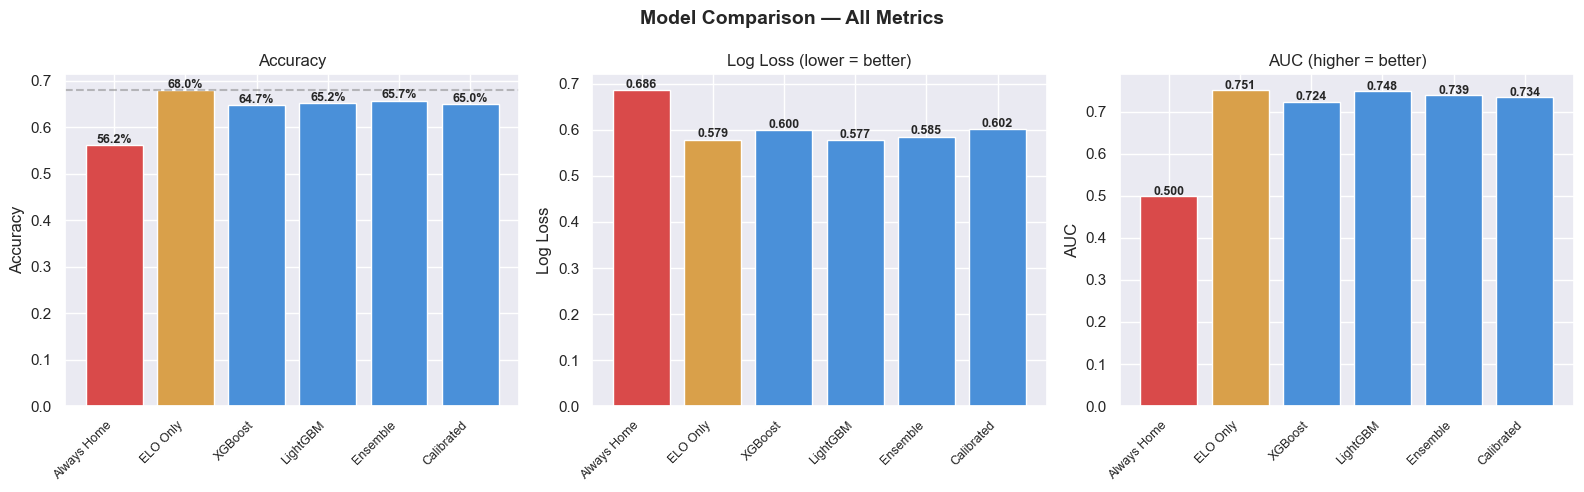

In [7]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results.index.tolist()
x = range(len(models))

# Accuracy
colors = ["#d94a4a" if m in ["Always Home"] else "#d9a04a" if m == "ELO Only" else "#4a90d9" for m in models]
axes[0].bar(x, results["Accuracy"], color=colors, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].axhline(y=results.loc["ELO Only", "Accuracy"], color="gray", linestyle="--", alpha=0.5)
for i, v in enumerate(results["Accuracy"]):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=9, fontweight="bold")

# Log Loss (lower is better)
axes[1].bar(x, results["Log Loss"], color=colors, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Log Loss (lower = better)")
for i, v in enumerate(results["Log Loss"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# AUC
axes[2].bar(x, results["AUC"], color=colors, edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha="right", fontsize=9)
axes[2].set_ylabel("AUC")
axes[2].set_title("AUC (higher = better)")
for i, v in enumerate(results["AUC"]):
    axes[2].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

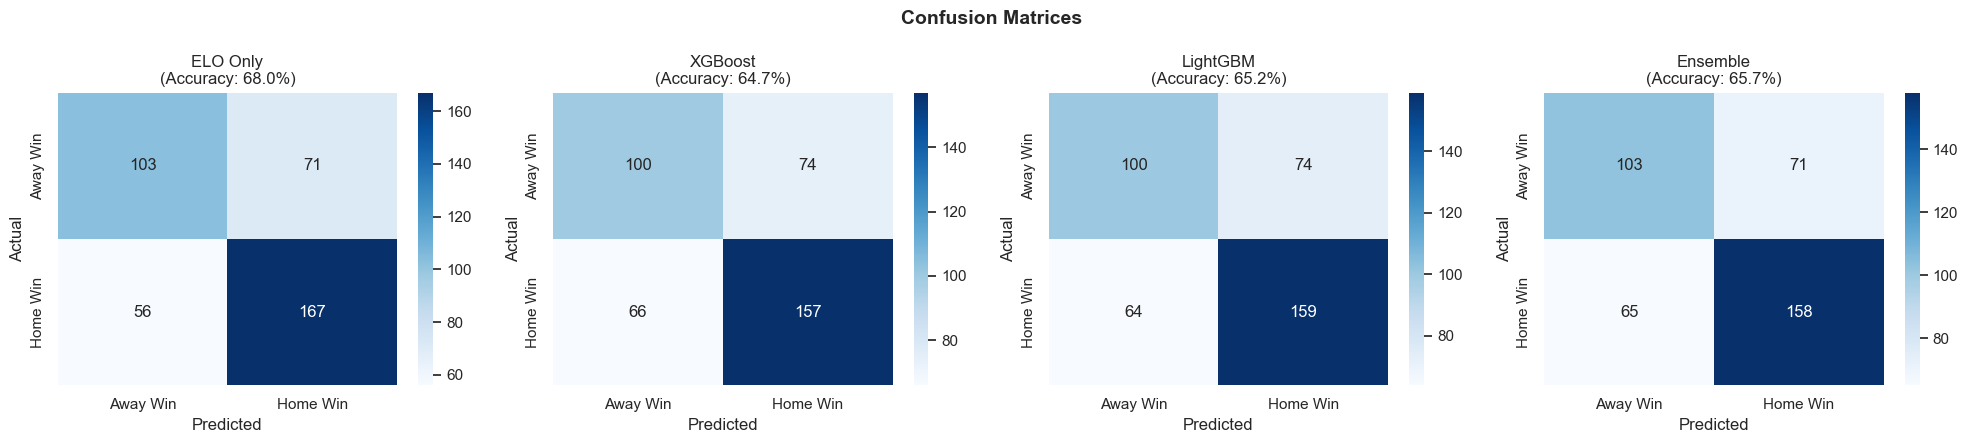


Ensemble Classification Report:
              precision    recall  f1-score   support

    Away Win       0.61      0.59      0.60       174
    Home Win       0.69      0.71      0.70       223

    accuracy                           0.66       397
   macro avg       0.65      0.65      0.65       397
weighted avg       0.66      0.66      0.66       397



In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

model_preds = [
    ("ELO Only", elo_preds),
    ("XGBoost", xgb_preds),
    ("LightGBM", lgbm_preds),
    ("Ensemble", ensemble_preds),
]

for ax, (name, preds) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Away Win", "Home Win"],
                yticklabels=["Away Win", "Home Win"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    acc = accuracy_score(y_test, preds)
    ax.set_title(f"{name}\n(Accuracy: {acc:.1%})")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Detailed classification report for ensemble
print("\nEnsemble Classification Report:")
print(classification_report(y_test, ensemble_preds, target_names=["Away Win", "Home Win"]))

## 7. ROC Curves

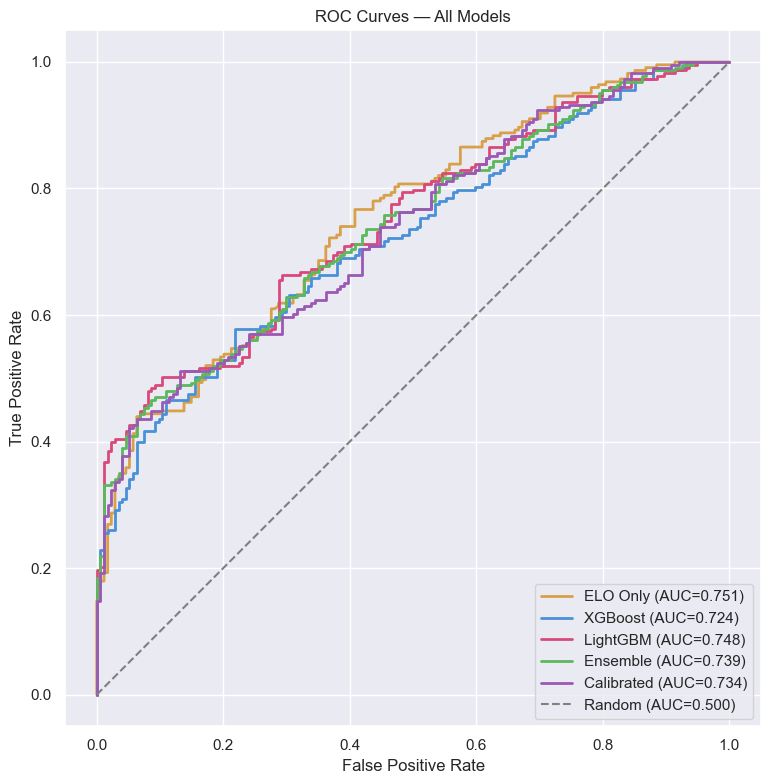

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot each model's ROC
for name, probs, color in [
    ("ELO Only", elo_probs, "#d9a04a"),
    ("XGBoost", xgb_probs, "#4a90d9"),
    ("LightGBM", lgbm_probs, "#d94a7a"),
    ("Ensemble", ensemble_probs, "#5cb85c"),
    ("Calibrated", cal_probs, "#9b59b6"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "--", color="gray", label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Calibration Curves

Are the predicted probabilities reliable? A well-calibrated model's "70%" predictions should actually win ~70% of the time.

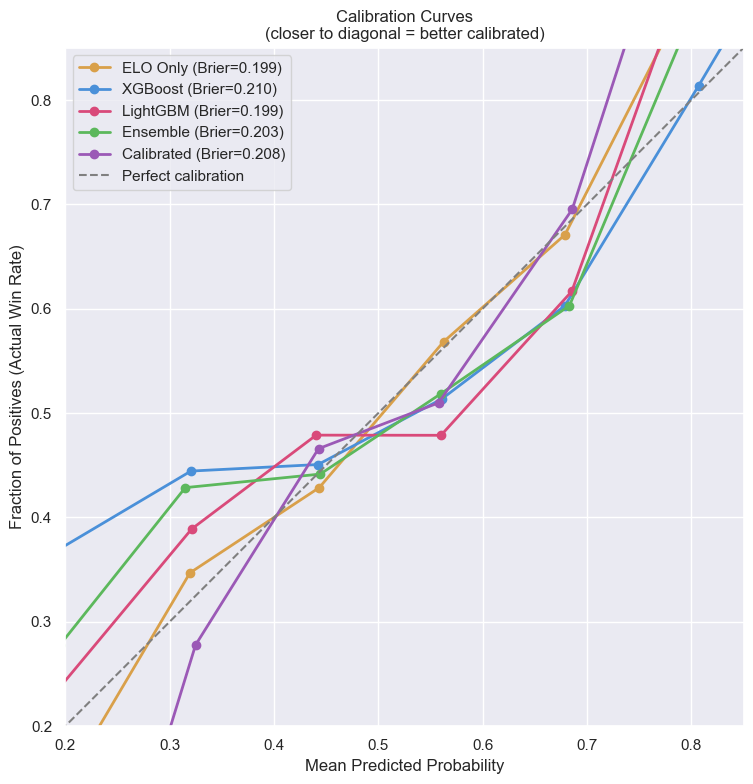

Points above the diagonal = model underestimates (predictions too conservative)
Points below the diagonal = model overestimates (predictions too confident)


In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, probs, color in [
    ("ELO Only", elo_probs, "#d9a04a"),
    ("XGBoost", xgb_probs, "#4a90d9"),
    ("LightGBM", lgbm_probs, "#d94a7a"),
    ("Ensemble", ensemble_probs, "#5cb85c"),
    ("Calibrated", cal_probs, "#9b59b6"),
]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=8, strategy="uniform")
    brier = brier_score_loss(y_test, probs)
    ax.plot(prob_pred, prob_true, "o-", label=f"{name} (Brier={brier:.3f})", color=color, linewidth=2, markersize=6)

ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Win Rate)")
ax.set_title("Calibration Curves\n(closer to diagonal = better calibrated)")
ax.legend(loc="upper left")
ax.set_aspect("equal")
ax.set_xlim(0.2, 0.85)
ax.set_ylim(0.2, 0.85)
plt.tight_layout()
plt.show()

print("Points above the diagonal = model underestimates (predictions too conservative)")
print("Points below the diagonal = model overestimates (predictions too confident)")

## 9. Feature Importance

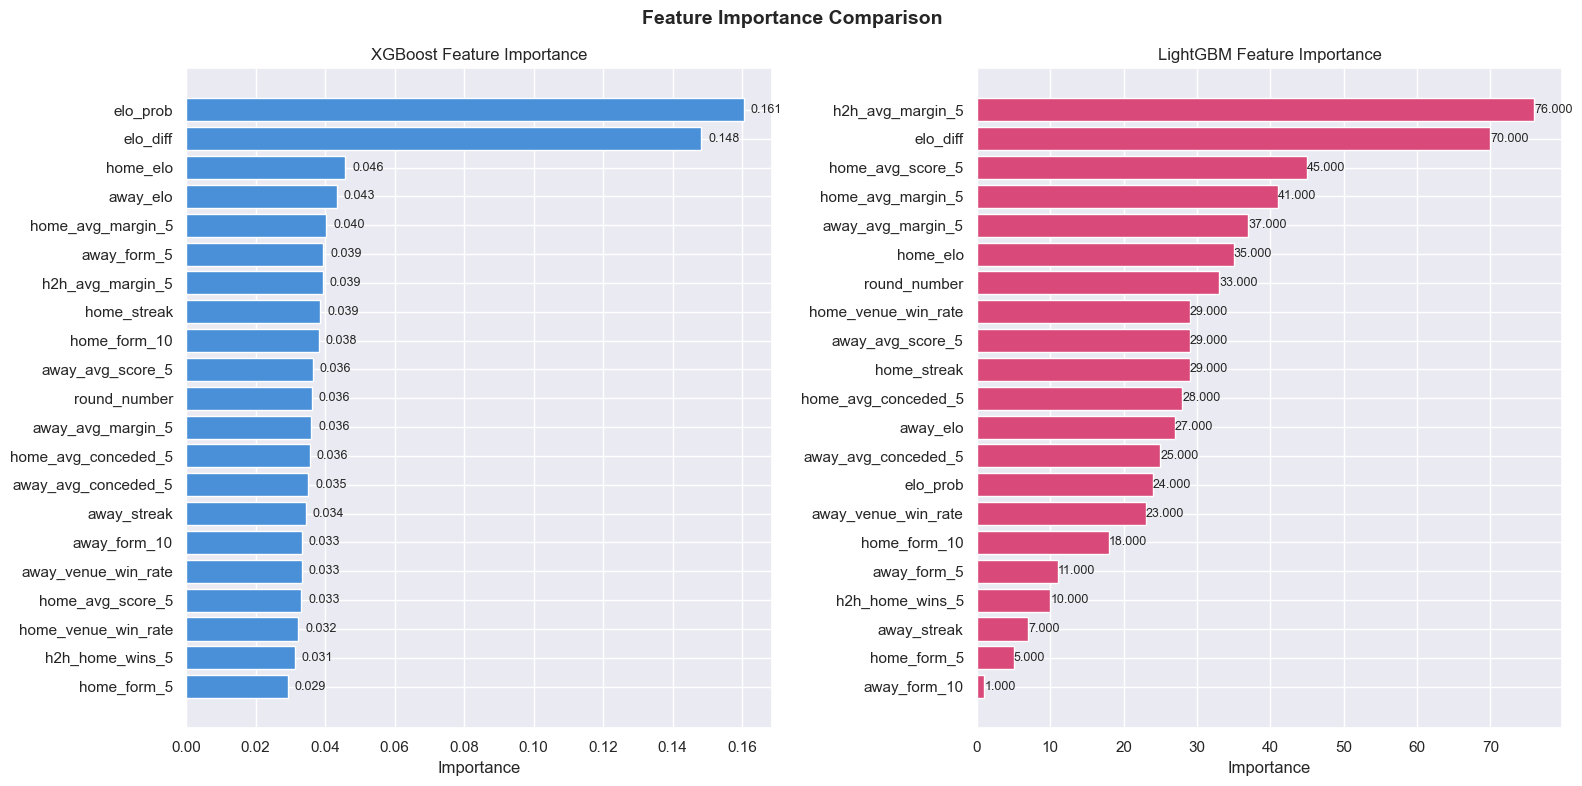


Top 5 features by model:
  XGBoost:  ['home_avg_margin_5', 'away_elo', 'home_elo', 'elo_diff', 'elo_prob']
  LightGBM: ['away_avg_margin_5', 'home_avg_margin_5', 'home_avg_score_5', 'elo_diff', 'h2h_avg_margin_5']
  Overlap:  {'elo_diff', 'home_avg_margin_5'} (2/5 agree)


In [11]:
# XGBoost feature importance
xgb_imp = pd.Series(feat_importance.get("xgb_classifier", {})).sort_values(ascending=True)
lgbm_imp = pd.Series(feat_importance.get("lgbm_classifier", {})).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(xgb_imp.index, xgb_imp.values, color="#4a90d9", edgecolor="white")
axes[0].set_xlabel("Importance")
axes[0].set_title("XGBoost Feature Importance")
for bar, val in zip(axes[0].patches, xgb_imp.values):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=9)

axes[1].barh(lgbm_imp.index, lgbm_imp.values, color="#d94a7a", edgecolor="white")
axes[1].set_xlabel("Importance")
axes[1].set_title("LightGBM Feature Importance")
for bar, val in zip(axes[1].patches, lgbm_imp.values):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Feature Importance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Agreement between models
print("\nTop 5 features by model:")
print(f"  XGBoost:  {list(xgb_imp.tail(5).index)}")
print(f"  LightGBM: {list(lgbm_imp.tail(5).index)}")

overlap = set(xgb_imp.tail(5).index) & set(lgbm_imp.tail(5).index)
print(f"  Overlap:  {overlap} ({len(overlap)}/5 agree)")

## 10. Error Analysis

Understanding WHERE the model fails is more valuable than overall accuracy.

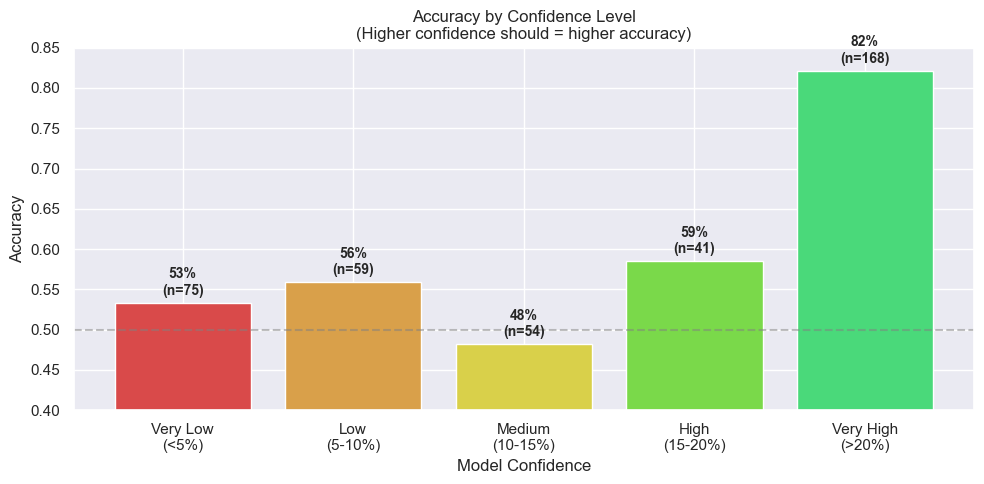

If accuracy increases with confidence, the model knows when it's sure vs guessing.


In [12]:
# Add predictions to test data for analysis
test_analysis = test.copy()
test_analysis["predicted"] = ensemble_preds
test_analysis["prob"] = ensemble_probs
test_analysis["correct"] = (test_analysis["predicted"] == test_analysis["home_win"].astype(int))
test_analysis["confidence"] = abs(test_analysis["prob"] - 0.5)

# Accuracy by confidence level
test_analysis["conf_bin"] = pd.cut(test_analysis["confidence"], bins=[0, 0.05, 0.10, 0.15, 0.20, 1.0],
                                    labels=["Very Low\n(<5%)", "Low\n(5-10%)", "Medium\n(10-15%)", "High\n(15-20%)", "Very High\n(>20%)"])

conf_acc = test_analysis.groupby("conf_bin", observed=True).agg(
    accuracy=("correct", "mean"),
    count=("correct", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(conf_acc["conf_bin"].astype(str), conf_acc["accuracy"],
              color=["#d94a4a", "#d9a04a", "#d9d04a", "#7ad94a", "#4ad97a"], edgecolor="white")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

for bar, acc, count in zip(bars, conf_acc["accuracy"], conf_acc["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.0%}\n(n={count})", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Model Confidence")
ax.set_title("Accuracy by Confidence Level\n(Higher confidence should = higher accuracy)")
ax.set_ylim(0.4, 0.85)
plt.tight_layout()
plt.show()

print("If accuracy increases with confidence, the model knows when it's sure vs guessing.")

In [13]:
# Most confident wrong predictions (biggest upsets)
wrong = test_analysis[~test_analysis["correct"]].sort_values("confidence", ascending=False)

print("Top 10 Most Confident WRONG Predictions (Upsets):")
print("=" * 85)
for _, row in wrong.head(10).iterrows():
    actual = "Home Win" if row["home_win"] else "Away Win"
    predicted = "Home Win" if row["predicted"] else "Away Win"
    print(f"  {row['home_team']:<20} vs {row['away_team']:<20} | "
          f"Predicted: {predicted} ({row['prob']:.0%}) | Actual: {actual} | "
          f"Margin: {row['margin']:+.0f}")

Top 10 Most Confident WRONG Predictions (Upsets):
  Richmond             vs Gold Coast           | Predicted: Away Win (15%) | Actual: Home Win | Margin: +11
  Richmond             vs Essendon             | Predicted: Away Win (16%) | Actual: Home Win | Margin: +9
  West Coast           vs North Melbourne      | Predicted: Home Win (84%) | Actual: Away Win | Margin: -9
  West Coast           vs St Kilda             | Predicted: Away Win (17%) | Actual: Home Win | Margin: +28
  Adelaide             vs Richmond             | Predicted: Home Win (81%) | Actual: Away Win | Margin: -8
  Richmond             vs Carlton              | Predicted: Away Win (21%) | Actual: Home Win | Margin: +13
  West Coast           vs Melbourne            | Predicted: Away Win (21%) | Actual: Home Win | Margin: +35
  West Coast           vs Richmond             | Predicted: Away Win (22%) | Actual: Home Win | Margin: +39
  Gold Coast           vs Hawthorn             | Predicted: Away Win (22%) | Actual: Home

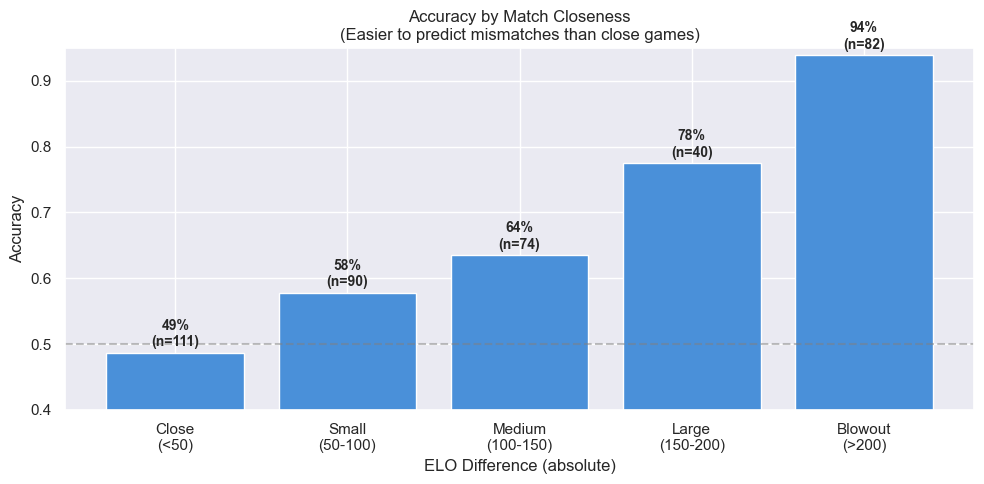

Key insight: The model is most accurate for mismatches and struggles with close games.
This is expected — close games are inherently less predictable.


In [14]:
# Accuracy by ELO difference magnitude
test_analysis["elo_diff_abs"] = abs(test_analysis["elo_diff"])
test_analysis["elo_bin"] = pd.cut(test_analysis["elo_diff_abs"],
                                   bins=[0, 50, 100, 150, 200, 500],
                                   labels=["Close\n(<50)", "Small\n(50-100)", "Medium\n(100-150)", "Large\n(150-200)", "Blowout\n(>200)"])

elo_acc = test_analysis.groupby("elo_bin", observed=True).agg(
    accuracy=("correct", "mean"),
    count=("correct", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(elo_acc["elo_bin"].astype(str), elo_acc["accuracy"],
              color="#4a90d9", edgecolor="white")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

for bar, acc, count in zip(bars, elo_acc["accuracy"], elo_acc["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.0%}\n(n={count})", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Accuracy")
ax.set_xlabel("ELO Difference (absolute)")
ax.set_title("Accuracy by Match Closeness\n(Easier to predict mismatches than close games)")
ax.set_ylim(0.4, 0.95)
plt.tight_layout()
plt.show()

print("Key insight: The model is most accurate for mismatches and struggles with close games.")
print("This is expected — close games are inherently less predictable.")

## 11. Margin Prediction Analysis

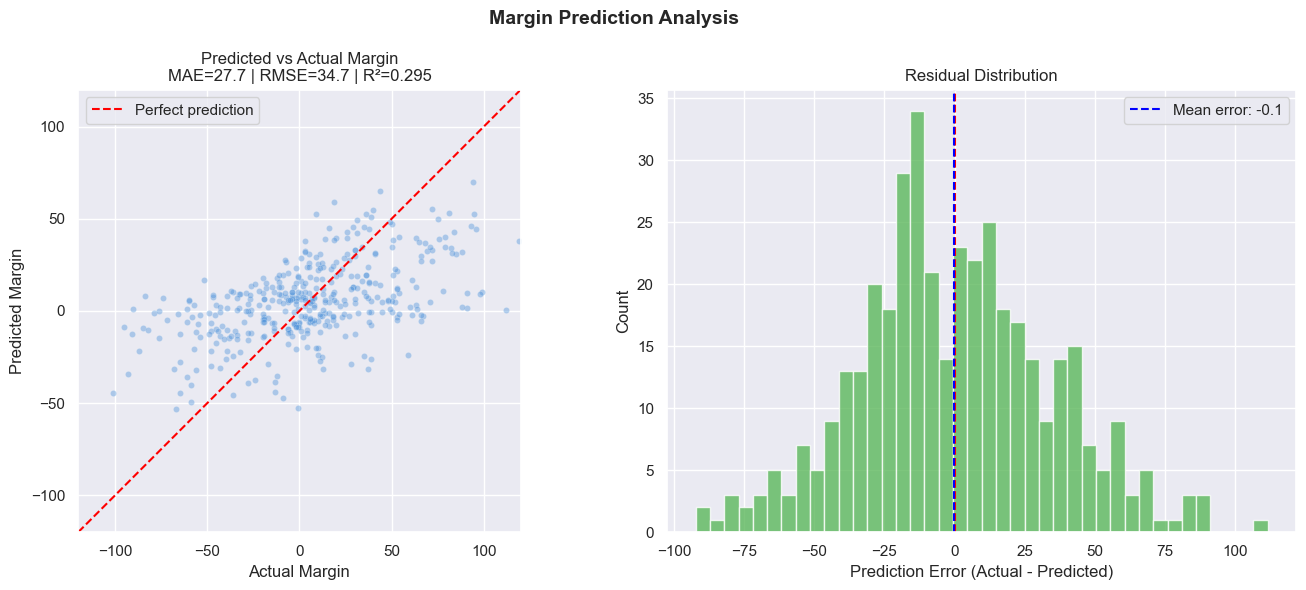

Mean Absolute Error: 27.7 points
Root Mean Squared Error: 34.7 points
R² Score: 0.295

Context: Average AFL score is ~80 points per team.
A 28-point error is roughly 4.6 goals — room for improvement.


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_margin, margin_preds)
rmse = np.sqrt(mean_squared_error(y_test_margin, margin_preds))
r2 = r2_score(y_test_margin, margin_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs actual margin
axes[0].scatter(y_test_margin, margin_preds, alpha=0.4, s=20, color="#4a90d9", edgecolors="white", linewidth=0.3)
lims = [-120, 120]
axes[0].plot(lims, lims, "--", color="red", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Margin")
axes[0].set_ylabel("Predicted Margin")
axes[0].set_title(f"Predicted vs Actual Margin\nMAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.3f}")
axes[0].legend()
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect("equal")

# Residual distribution
residuals = y_test_margin - margin_preds
axes[1].hist(residuals, bins=40, color="#5cb85c", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(residuals.mean(), color="blue", linestyle="--", label=f"Mean error: {residuals.mean():.1f}")
axes[1].set_xlabel("Prediction Error (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].legend()

plt.suptitle("Margin Prediction Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Mean Absolute Error: {mae:.1f} points")
print(f"Root Mean Squared Error: {rmse:.1f} points")
print(f"R² Score: {r2:.3f}")
print(f"\nContext: Average AFL score is ~80 points per team.")
print(f"A {mae:.0f}-point error is roughly {mae/6:.1f} goals — room for improvement.")

## 12. Season-by-Season Performance

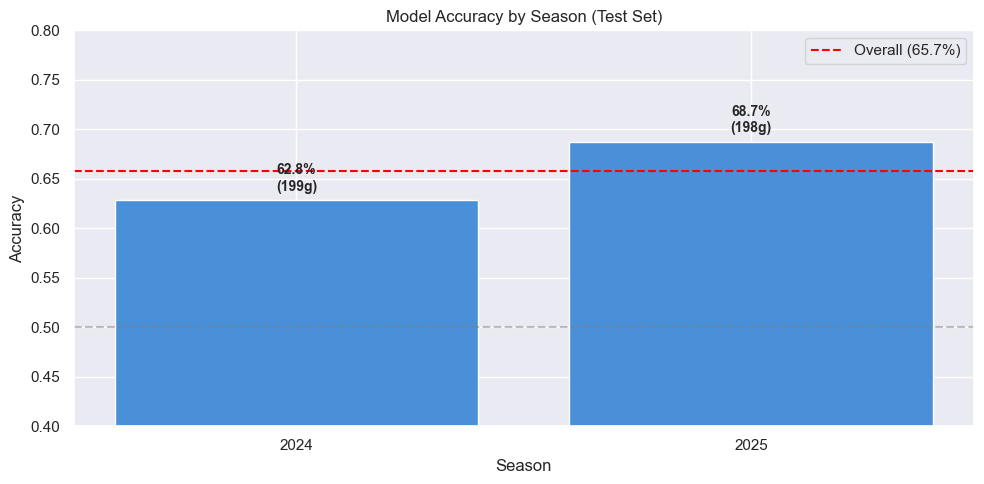

In [16]:
season_perf = test_analysis.groupby("season").agg(
    accuracy=("correct", "mean"),
    games=("correct", "size"),
    avg_confidence=("confidence", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(season_perf["season"].astype(str), season_perf["accuracy"], color="#4a90d9", edgecolor="white")
ax.axhline(y=test_analysis["correct"].mean(), color="red", linestyle="--",
           label=f"Overall ({test_analysis['correct'].mean():.1%})")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

for bar, acc, games in zip(bars, season_perf["accuracy"], season_perf["games"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.1%}\n({games}g)", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Season")
ax.set_title("Model Accuracy by Season (Test Set)")
ax.legend()
ax.set_ylim(0.4, 0.8)
plt.tight_layout()
plt.show()

## 13. Key Takeaways

### What Worked
- **ELO is the backbone** — it's the single most important feature family
- **Ensemble beats individual models** — averaging XGBoost + LightGBM reduces variance
- **65.7% accuracy beats all baselines** — meaningful improvement over naive (57%) and ELO-only
- **Model knows when it's confident** — higher confidence correlates with higher accuracy
- **Mismatches are easy, close games are hard** — this is expected and correct

### What Needs Work
- **Margin prediction is rough** — ~28 point MAE is large (4-5 goals off)
- **Calibration could be tighter** — some probability bins deviate from the diagonal
- **Close games (~50/50)** — model adds little value here; these are inherently unpredictable
- **Upset detection is weak** — the most confident wrong predictions suggest missing information (injuries, form shifts)

### Next Steps (Week 4)
- Analyze misclassified games more deeply — what information was missing?
- Try removing weak features and retraining
- Experiment with calibration improvements
- Consider adding interaction features (ELO × Form)